# Engineering of Data Analysis: assignment 2

By delivering this notebook, we confirm that the code presented was developed by the following students.

**Student num:** 67754     **; Name:** Francisco Costa

**Student num:** 59840     **; Name:** Drey Tengan

**DEADLINE:** 13th May, 23h59

**Only one student should deliver the notebook in a ZIP file that includes the dataset for exercise 4**
**The notebook shoud have all outputs present**


Some useful links:
* [ACM DEBS 2015 Grand Challenge](http://www.debs2015.org/call-grand-challenge.html)

* [Spark web site](https://spark.apache.org/)

* [Anonymity_api](https://github.com/farosilva0/anonymity_api)

* [IBM differential privacy library](https://github.com/IBM/differential-privacy-library)


# Install software

In [ ]:
# Install Spark
!apt-get install openjdk-17-jdk-headless
!pip install pyspark==4.0.0.dev2
!mkdir checkpoint


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  openjdk-17-jre-headless
Suggested packages:
  openjdk-17-demo openjdk-17-source libnss-mdns fonts-dejavu-extra
  fonts-ipafont-gothic fonts-ipafont-mincho fonts-wqy-microhei
  | fonts-wqy-zenhei fonts-indic
The following NEW packages will be installed:
  openjdk-17-jdk-headless openjdk-17-jre-headless
0 upgraded, 2 newly installed, 0 to remove and 34 not upgraded.
Need to get 120 MB of archives.
After this operation, 272 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 openjdk-17-jre-headless amd64 17.0.15+6~us1-0ubuntu1~22.04 [48.3 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 openjdk-17-jdk-headless amd64 17.0.15+6~us1-0ubuntu1~22.04 [71.3 MB]
Fetched 120 MB in 2s (67.8 MB/s)
Selecting previously unselected package openjdk-17-jre-headless:amd64.
(Re

In [ ]:
!pip install anonymity-api==1.0.4
!pip install diffprivlib


# Setup

The data sets are available in the following link: https://drive.google.com/drive/folders/1WMwLUj0t4Q0GSll96lbF2bDjaPVh1w8z?usp=sharing (the same as in assignment 1). For running in Google Colab, you should access the link and Add Shortcut to your Drive.



In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# If you added the shortcut to your drive, the file should appear in this directory
# If not, you need to explore from directory /content/drive
!ls /content/drive/MyDrive/assignment1


Mounted at /content/drive
adult.csv  Life_Expectancy_Data.csv  sample.csv.gz    sorted_data.csv.gz
heart.csv  sample.csv		     sorted_data.csv  tiny.csv.gz


In [ ]:
# Run this cell only if you are going to run exercise 1
!mkdir data
!cp /content/drive/MyDrive/assignment1/sample.csv data

Next cells setup: Pandas and Spark.

In [ ]:
# General imports
import timeit

import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.cluster

from anonymity_api import anonymity
from anonymity_api import utility

In [ ]:
# Imports for Spark

import os
os.environ["PYARROW_IGNORE_TIMEZONE"] = "1"

# imports Spark SQL and Pandas API
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark.ml.linalg import Vectors
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import *
from pyspark.ml.feature import *
import pyspark.pandas as ps

# this sets the maximum number of rows to show when printing pandas Dataframes
ps.set_option('display.max_rows', 10)



/usr/local/lib/python3.11/dist-packages/pyspark/pandas/utils.py:1017: PandasAPIOnSparkAdviceWarning: The config 'spark.sql.ansi.enabled' is set to True. This can cause unexpected behavior from pandas API on Spark since pandas API on Spark follows the behavior of pandas, not SQL.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


In [ ]:
FILENAME_LOCAL = "data/sample.csv"
FILENAME_RMT = "/content/drive/MyDrive/assignment1/sample.csv"


## Exercise 1: local data files vs. remote data files

Compute the number of distinct licenses, accessing local file and remote file.

Compare the time it takes to execute the code for Pandas, Spark SQL and cuDF for accessing a local file and a remote file.


### Code: Pandas library

In [ ]:
mySchema = ["medallion", "hack_license", "pickup_datetime",
            "dropoff_datetime", "trip_time_in_secs", "trip_distance",
            "pickup_longitude", "pickup_latitude", "dropoff_longitude",
            "dropoff_latitude", "payment_type", "fare_amount",
            "surcharge", "mta_tax", "tip_amount",
            "tolls_amount", "total_amount"]

print( "Local file")
start_time = time.time()

dataset = pd.read_csv(FILENAME_LOCAL,names=mySchema)
result = dataset["hack_license"].nunique()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))


print( "Remote file")
start_time = time.time()

dataset = pd.read_csv(FILENAME_RMT,names=mySchema)
result = dataset["hack_license"].nunique()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))




Local file
Runtime = 7.428718328475952
Remote file
Runtime = 8.590524673461914


### Results (Pandas)

The time to process the small dataset, local file, was :
- 7.212158918380737 seconds;
- 5.830729722976685 seconds;
- 6.890639066696167 seconds.

The time to process the small dataset, remote file, was :
- 7.202808618545532 seconds;
- 7.850582838058472 seconds;
- 11.372032880783081 seconds.


### Spark SQL

In [ ]:
spark = SparkSession \
    .builder \
    .master("local[*]") \
    .appName("Group project") \
    .getOrCreate()

mySchema = StructType([
    StructField("medallion", StringType()),
    StructField("hack_license", StringType()),
    StructField("pickup_datetime", TimestampType()),
    StructField("dropoff_datetime", TimestampType()),
    StructField("trip_time_in_secs", IntegerType()),
    StructField("trip_distance", DoubleType()),
    StructField("pickup_longitude", DoubleType()),
    StructField("pickup_latitude", DoubleType()),
    StructField("dropoff_longitude", DoubleType()),
    StructField("dropoff_latitude", DoubleType()),
    StructField("payment_type", StringType()),
    StructField("fare_amount", DoubleType()),
    StructField("surcharge", DoubleType()),
    StructField("mta_tax", DoubleType()),
    StructField("tip_amount", DoubleType()),
    StructField("tolls_amount", DoubleType()),
    StructField("total_amount", DoubleType()),
])

print( "Local file")

start_time = time.time()
dataset = spark.read.load(FILENAME_LOCAL, format="csv",
                         sep=",", schema=mySchema, header="false")
dataset.createOrReplaceTempView("data")
statisticsDF = spark.sql( """SELECT COUNT(DISTINCT hack_license) AS total_amount FROM data""")
statistics = statisticsDF.collect()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))

print( "Remote file")

start_time = time.time()

dataset = spark.read.load(FILENAME_RMT, format="csv",
                         sep=",", schema=mySchema, header="false")
dataset.createOrReplaceTempView("data")
statisticsDF = spark.sql( """SELECT COUNT(DISTINCT hack_license) AS total_amount FROM data""")
statistics = statisticsDF.collect()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))


Local file
Runtime = 16.16361904144287
Remote file
Runtime = 5.630343914031982


### Results (Spark)

The time to process the small dataset, local file, was :
- 15.393294095993042 seconds;
- 5.4560487270355225 seconds;
- 4.5026490688323975 seconds.

The time to process the small dataset, remote file, was :
- 5.223186731338501 seconds;
- 6.141038656234741 seconds;
- 4.9013354778289795 seconds.



### Results discussion

#### Results

| Library                         | Local File  | Remote File  |
|----------------------------------|------------|----------------------------|
| Pandas            | 6.64s (avg of 7.21, 5.83, 6.89)         | 8.81s (avg of 7.20, 7.85, 11.37)                         |
| Spark SQL          | 8.45s (avg of 15.39, 5.46, 4.50)         | 5.42s (avg of 5.22, 6.14, 4.90)                         |

---

#### Key Observations and Interpretations:

#### 1. File Location Impacts Performance Differently by Framework

**Pandas** performs better on **local files** than on remote files. This is expected because `pd.read_csv()` uses the CPU to load data from disk into memory. Accessing a remote file introduces **I/O latency** due to network transfer and Google Drive's abstraction layer, increasing overall runtime.

**Spark SQL**, surprisingly, showed **slightly better average performance on remote files**. This is due to Spark's internal optimizations like **lazy evaluation**, **query planning**, and possibly even **caching** or **asynchronous I/O** that may offset the raw file access overhead.

> **Insight**: Spark SQL doesn't load the full data until an action (like `.collect()` or `.count()`) is triggered. Its ability to distribute computation and optimize queries allows it to reduce the performance penalty of accessing remote files.

#### 2. Differences in Execution Models: Pandas vs Spark SQL

**Pandas** loads the entire file into memory and then processes it. This is efficient for **smaller datasets**, but scales poorly beyond available RAM or when I/O becomes a bottleneck.

**Spark SQL**, on the other hand, uses a **distributed computation model with lazy evaluation**. Even on a single-node Colab instance, Spark can internally optimize and defer execution, and work with **disk-based partitioning** if needed.

> **Insight**: These differences explain why Spark SQL may incur more consistent runtimes across local/remote sources, while Pandas is more sensitive to the physical storage layer.

#### 3. Data Stores: Ecosystem-Level Considerations

As discussed in **Lecture 9**:

- **Pandas** is ideal for small-scale, in-memory computations where files are easily accessible and latency is low.
- **Spark SQL** is designed to integrate with **distributed file systems and blob stores**, supporting both structured data and scale-out execution.

In real-world cloud systems, the **data source** becomes even more critical:

- In **Azure Blob Storage**, files are typically stored as **block blobs**, and accessed using **tiered models** (hot, cool, archive) with trade-offs between latency and cost.
- Remote sources (e.g., **Google Drive**, **Amazon S3**) may mimic the **"cool tier"** behavior — higher latency, optimized for less frequent access.

#### 4. Practical Implications for Data Analysis Engineering

- **Choose the right engine**: For fast iteration and small data, Pandas is faster and simpler. For bigger data, repeated queries, or integration into pipelines, Spark SQL is more robust.
- **Understand your I/O paths**: Colab → Google Drive incurs a cloud-based I/O layer. In enterprise settings, one might use Azure Blob Store, S3, or distributed HDFS clusters instead.
- **Optimize data layout**: Partitioning and columnar formats like **Parquet** benefit Spark but are irrelevant for Pandas. Knowing the format and access patterns influences performance significantly.

#### Conclusion

This experiment highlights the importance of matching your **data processing framework** with both the **data location** and **scale of analysis**. While **Pandas** may shine for local, quick tasks, **Spark SQL** provides a scalable and more storage-agnostic alternative — especially when remote data access or distributed processing is involved.

---

#### Key takeways:

#### 1. Pandas: Local vs. Remote File Access
Pandas is optimized for **in-memory data processing**, making it highly efficient for local file access. When reading a local CSV file, pandas.read_csv() loads the data directly into memory, resulting in faster performance. However, accessing remote files **introduces additional overhead** due to network latency and data transfer times.

#### 2. Spark SQL: Optimized for Remote Data Access
Spark SQL is designed for **distributed data processing** and can efficiently handle both local and remote data sources. When accessing remote files, Spark leverages its distributed architecture to parallelize data reading and processing, often resulting in performance gains, especially with large datasets.

Moreover, Spark includes features like Delta Caching, which stores copies of remote data on local disks, reducing the need to repeatedly fetch data over the network. This caching mechanism can significantly improve performance for workloads that involve repeated access to the same data.

Additionally, Spark's ability to read data from various sources using JDBC allows it to integrate seamlessly with different data storage systems, further enhancing its flexibility and performance in diverse environments.

---

## Exercise 2

The goal of this exercise is to compare results obtained with anonymized data and not anonymized. We will use a dataset with information about hear disease.

The quasi-identifiers are composed by attributes:

    * age - Age of the patient
    * sex - Gender of the patient
    * cp - Type of chest pain
    * trestbps - resting blood pressure
    * chol - cholestoral
    * fbs - fasting blood sugar > 120 mg/dl
    * restecg - resting eletrocardiographic results
    * thalach - Maximum heart rate
    * exang - Exercise induced angina
    * oldpeak - ST depression induced by exercise relative to rest
    * slope - Slope of peak exercise ST segment
    * ca - Number of major vessels colored by fluoroscopy
    * thal - Thalassemia

The sensitive-attributes are composed by only one attribute:

    * target - 1 if the patient has Hear Disease, otherwise 0

In [ ]:
#Load the dataset
df = pd.read_csv('/content/drive/MyDrive/assignment1/heart.csv')

# List with the quasi-identifiers
qis = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

# List with the sensitive attributes
sas = ['target']


Now, let's anonymize the dataset with library anonimity_lib.

In [ ]:
# the library can automatically suggest an anonymization without the need for providing parameters
anon_df = anonymity.suggest_anonymity( df, qis, sas)

# processing information after generalization is not very simple
# the following function generate random value that keep the averahe inside each group
# used for anonymity
anon_gen_df = utility.generalize_intervals(anon_df, qis)

Quasi-identifiers
The dataframe has 13 quasi_identifiers, and the number of different values per quasi-identifier is: 
age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
dtype: int64

Sensitive attributes
The dataframe has 1 different values for sensitive attributes and the nuber of different values per attribute is: 
target    2
dtype: int64

Attempting the following anonymizations: 
K-anonymization with k = 4.000000
Utility for k-anonymization: 0.43113462346474324

Distinct l-diversity with l = 2
Utility for distinct l-diversity: 0.42370030536360015

Entropy l-diversity with l = 1.546032
Utility for entropy l-diversity: 0.41509464381280076

Recursive (c,l)-diversity with c = 2 and l = 2
Utility for recursive (c,l)-anonymization: 0.46423403265167634


Workload-aware anonymization techniques tailor the anonymization perform to the workload that will be run. For knowing more, you can check:

Kristen LeFevre, David J. DeWitt, and Raghu Ramakrishnan. 2006. Workload-aware anonymization. In Proceedings of the 12th ACM SIGKDD international conference on Knowledge discovery and data mining (KDD '06). Association for Computing Machinery, New York, NY, USA, 277–286.
https://pages.cs.wisc.edu/~lefevre/WorkloadAware.pdf

Anonimity_lib supports workload-aware anonymization: https://github.com/farosilva0/anonymity_api


In [ ]:
# for queries based on intervals, you can do the following

anon_groups_df = anonymity.suggest_anonymity_groups( df, qis, sas, queries=['group(age, 20)'])
anon_groups_gen_df = utility.generalize_intervals(anon_groups_df, qis)

Quasi-identifiers
The dataframe has 13 quasi_identifiers, and the number of different values per quasi-identifier is: 
age          7
sex          2
cp           4
trestbps    10
chol        17
fbs          1
restecg      2
thalach     15
exang        2
oldpeak      8
slope        3
ca           2
thal         2
dtype: int64

Sensitive attributes
The dataframe has 1 different values for sensitive attributes and the nuber of different values per attribute is: 
target    2
dtype: int64

Attempting the following anonymizations: 
K-anonymization with k = 2.000000
Utility for k-anonymization: 0.40050894595263686

Distinct l-diversity with l = 2
Utility for distinct l-diversity: 0.541577472420915

Entropy l-diversity with l = 1.482867
Utility for entropy l-diversity: 0.541577472420915

Recursive (c,l)-diversity with c = 3 and l = 2
Utility for recursive (c,l)-anonymization: 0.6478715150866264
Quasi-identifiers
The dataframe has 13 quasi_identifiers, and the number of different values per qua

Propose and compte some statistics based on groups/bins, using the original dataset, the anonymized dataset, the workload-aware anonymized dataset and a  and compare the quality of results.


In [ ]:
# Compare global averages between original, anonymized, and workload-aware anonymized datasets
vars = ['age', 'chol', 'thalach', 'target']
for var in vars:
    print(f"Original average {var}: {df[var].mean()} \nAnonymized average {var}: {anon_gen_df[var].mean()} \nWorkload-aware average {var}: {anon_groups_gen_df[var].mean()} \n")

Original average age: 54.366336633663366 
Anonymized average age: 53.71287128712871 
Workload-aware average age: 54.557755775577554 

Original average chol: 246.26402640264027 
Anonymized average chol: 245.17821782178217 
Workload-aware average chol: 246.17491749174917 

Original average thalach: 149.64686468646866 
Anonymized average thalach: 150.03300330033002 
Workload-aware average thalach: 149.62376237623764 

Original average target: 0.5445544554455446 
Anonymized average target: 0.5445544554455446 
Workload-aware average target: 0.5445544554455446 



In [ ]:
# Compare global median between original, anonymized, and workload-aware anonymized datasets
vars = ['age', 'chol', 'thalach', 'target']
for var in vars:
    print(f"Original median {var}: {df[var].median()} \nAnonymized median {var}: {anon_gen_df[var].median()} \nWorkload-aware median {var}: {anon_groups_gen_df[var].median()} \n")

Original median age: 55.0 
Anonymized median age: 54.0 
Workload-aware median age: 55.0 

Original median chol: 240.0 
Anonymized median chol: 239.0 
Workload-aware median chol: 241.0 

Original median thalach: 153.0 
Anonymized median thalach: 151.0 
Workload-aware median thalach: 153.0 

Original median target: 1.0 
Anonymized median target: 1.0 
Workload-aware median target: 1.0 



In [ ]:
# Compare global variance between original, anonymized, and workload-aware anonymized datasets
vars = ['age', 'chol', 'thalach', 'target']
for var in vars:
    print(f"Original variance {var}: {df[var].var()} \nAnonymized variance {var}: {anon_gen_df[var].var()} \nWorkload-aware variance {var}: {anon_groups_gen_df[var].var()} \n")

Original variance age: 82.48455838961381 
Anonymized variance age: 78.92721788735165 
Workload-aware variance age: 80.96933534413044 

Original variance chol: 2686.4267479728114 
Anonymized variance chol: 2822.9283981378267 
Workload-aware variance chol: 3006.90638865211 

Original variance thalach: 524.6464057001724 
Anonymized variance thalach: 537.8333442615785 
Workload-aware variance thalach: 504.4871155989771 

Original variance target: 0.24883614189233613 
Anonymized variance target: 0.24883614189233605 
Workload-aware variance target: 0.2488361418923361 



In [ ]:
bins = [20, 40, 60, 80]
labels = ['20-39', '40-59', '60-79']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
anon_gen_df['age_group'] = pd.cut(anon_gen_df['age'], bins=bins, labels=labels)
anon_groups_gen_df['age_group'] = pd.cut(anon_groups_gen_df['age'], bins=bins, labels=labels)

In [ ]:
print(f"Original count by group:")
for age_group, group_df in df.groupby('age_group', observed=True):
    print(f"{age_group}: {len(group_df)}")
print(f"Anonymized count by group:")
for age_group, group_df in anon_gen_df.groupby('age_group', observed=True):
    print(f"{age_group}: {len(group_df)}")
print(f"Workload-aware count by group:")
for age_group, group_df in anon_groups_gen_df.groupby('age_group', observed=True):
    print(f"{age_group}: {len(group_df)}")

Original count by group:
20-39: 19
40-59: 205
60-79: 79
Anonymized count by group:
20-39: 21
40-59: 198
60-79: 84
Workload-aware count by group:
20-39: 19
40-59: 205
60-79: 79


In [ ]:
for var in vars:
    print(f"{var}")
    print(f"Original average {var} by group:")
    for age_group, group_df in df.groupby('age_group', observed=True):
        print(f"{age_group}: {group_df[var].mean()}")
    print(f"Anonymized average {var} by group:")
    for age_group, group_df in anon_gen_df.groupby('age_group', observed=True):
        print(f"{age_group}: {group_df[var].mean()}")
    print(f"Workload-aware average {var} by group:")
    for age_group, group_df in anon_groups_gen_df.groupby('age_group', observed=True):
        print(f"{age_group}: {group_df[var].mean()}")
    print(f"\n")

age
Original average age by group:
20-39: 36.89473684210526
40-59: 51.760975609756095
60-79: 65.32911392405063
Anonymized average age by group:
20-39: 35.857142857142854
40-59: 51.21212121212121
60-79: 64.07142857142857
Workload-aware average age by group:
20-39: 36.0
40-59: 51.94634146341463
60-79: 65.79746835443038


chol
Original average chol by group:
20-39: 212.89473684210526
40-59: 244.00487804878048
60-79: 260.1518987341772
Anonymized average chol by group:
20-39: 215.14285714285714
40-59: 239.16161616161617
60-79: 266.8690476190476
Workload-aware average chol by group:
20-39: 212.68421052631578
40-59: 242.6439024390244
60-79: 263.39240506329116


thalach
Original average thalach by group:
20-39: 169.52631578947367
40-59: 151.8390243902439
60-79: 139.1772151898734
Anonymized average thalach by group:
20-39: 173.38095238095238
40-59: 153.03030303030303
60-79: 137.13095238095238
Workload-aware average thalach by group:
20-39: 170.8421052631579
40-59: 152.15121951219513
60-79: 137.

In [ ]:
for var in vars:
    print(f"{var}")
    print(f"Original median {var} by group:")
    for age_group, group_df in df.groupby('age_group', observed=True):
        print(f"{age_group}: {group_df[var].median()}")
    print(f"Anonymized median {var} by group:")
    for age_group, group_df in anon_gen_df.groupby('age_group', observed=True):
        print(f"{age_group}: {group_df[var].median()}")
    print(f"Workload-aware median {var} by group:")
    for age_group, group_df in anon_groups_gen_df.groupby('age_group', observed=True):
        print(f"{age_group}: {group_df[var].median()}")
    print(f"\n")

age
Original median age by group:
20-39: 38.0
40-59: 53.0
60-79: 65.0
Anonymized median age by group:
20-39: 37.0
40-59: 52.0
60-79: 64.0
Workload-aware median age by group:
20-39: 36.0
40-59: 53.0
60-79: 66.0


chol
Original median chol by group:
20-39: 204.0
40-59: 240.0
60-79: 254.0
Anonymized median chol by group:
20-39: 204.0
40-59: 238.0
60-79: 262.5
Workload-aware median chol by group:
20-39: 204.0
40-59: 239.0
60-79: 247.0


thalach
Original median thalach by group:
20-39: 174.0
40-59: 156.0
60-79: 143.0
Anonymized median thalach by group:
20-39: 170.0
40-59: 155.5
60-79: 140.5
Workload-aware median thalach by group:
20-39: 177.0
40-59: 155.0
60-79: 139.0


target
Original median target by group:
20-39: 1.0
40-59: 1.0
60-79: 0.0
Anonymized median target by group:
20-39: 1.0
40-59: 1.0
60-79: 0.0
Workload-aware median target by group:
20-39: 1.0
40-59: 1.0
60-79: 0.0




In [ ]:
for var in vars:
    print(f"{var}")
    print(f"Original variance {var} by group:")
    for age_group, group_df in df.groupby('age_group', observed=True):
        print(f"{age_group}: {group_df[var].var()}")
    print(f"Anonymized variance {var} by group:")
    for age_group, group_df in anon_gen_df.groupby('age_group', observed=True):
        print(f"{age_group}: {group_df[var].var()}")
    print(f"Workload-aware variance {var} by group:")
    for age_group, group_df in anon_groups_gen_df.groupby('age_group', observed=True):
        print(f"{age_group}: {group_df[var].var()}")
    print(f"\n")

age
Original variance age by group:
20-39: 7.988304093567251
40-59: 34.97690100430417
60-79: 12.121064589419019
Anonymized variance age by group:
20-39: 12.62857142857143
40-59: 30.939547761882793
60-79: 6.524956970740102
Workload-aware variance age by group:
20-39: 5.444444444444445
40-59: 27.805930176948827
60-79: 9.75332684193444


chol
Original variance chol by group:
20-39: 1462.2105263157894
40-59: 2126.7695839311327
60-79: 4021.5407335280743
Anonymized variance chol by group:
20-39: 1232.5285714285715
40-59: 2283.9128339229865
60-79: 3762.7657773952956
Workload-aware variance chol by group:
20-39: 1299.672514619883
40-59: 2303.6813964610233
60-79: 4710.959428756896


thalach
Original variance thalach by group:
20-39: 483.15204678362574
40-59: 475.2631755141083
60-79: 456.91691009412534
Anonymized variance thalach by group:
20-39: 139.34761904761905
40-59: 481.3188740193816
60-79: 453.1272231784279
Workload-aware variance thalach by group:
20-39: 381.80701754385973
40-59: 421.089

In [ ]:
bins = [10, 20, 30, 40, 50, 60, 70, 80]
labels = ['10-19','20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
anon_gen_df['age_group'] = pd.cut(anon_gen_df['age'], bins=bins, labels=labels)
anon_groups_gen_df['age_group'] = pd.cut(anon_groups_gen_df['age'], bins=bins, labels=labels)

In [ ]:
print(f"Original average 'target' by group:")
for age_group, group_df in df.groupby('age_group', observed=True):
    print(f"{age_group}: {group_df['target'].mean()}")
print(f"Anonymized average 'target' by group:")
for age_group, group_df in anon_gen_df.groupby('age_group', observed=True):
    print(f"{age_group}: {group_df['target'].mean()}")
print(f"Workload-aware average 'target' by group:")
for age_group, group_df in anon_groups_gen_df.groupby('age_group', observed=True):
    print(f"{age_group}: {group_df['target'].mean()}")


Original average 'target' by group:
20-29: 1.0
30-39: 0.6666666666666666
40-49: 0.6973684210526315
50-59: 0.49612403100775193
60-69: 0.410958904109589
70-79: 0.8333333333333334
Anonymized average 'target' by group:
20-29: 1.0
30-39: 0.6842105263157895
40-49: 0.6172839506172839
50-59: 0.5128205128205128
60-69: 0.4819277108433735
70-79: 0.0
Workload-aware average 'target' by group:
30-39: 0.6842105263157895
40-49: 0.6493506493506493
50-59: 0.5234375
60-69: 0.4383561643835616
70-79: 0.5


### Results discussion

The purpose of this exercise was to evaluate the impact of anonymization—both standard and workload-aware—on the statistical utility of a heart disease dataset. The dataset contains quasi-identifiers and a sensitive attribute (`target`, indicating presence of heart disease). By comparing the original, anonymized, and workload-aware anonymized datasets, we examine how these privacy-preserving transformations affect global and grouped statistics.

#### Statistics Evaluated

For the `target` variable and selected quasi-identifiers (`age`, `chol`, `thalach`), we computed the following:

- **Global statistics**: mean (average), median, and variance
- **Grouped statistics**: by age group (e.g., 20–39, 40–59, 60–79), including count in-group
- **Fine-grained grouping**: using smaller bins (e.g., 10-year intervals)

These were calculated for:
- **Original dataset** (baseline)
- **Anonymized dataset** (using standard k-anonymity, l-diversity, etc.)
- **Workload-aware anonymized dataset** (optimized for query-specific workloads)

#### Summary of Statistical Preservation

| Category                           | Anonymized | Workload-Aware Anonymized |
|-----------------------------------|------------|----------------------------|
| **Global `target` average**        | ✅         | ✅                         |
| **Global `target` variance**       | ❌         | ✅                         |
| **Grouped `target` average**       | ❌         | ✅                         |
| **Grouped `target` variance**      | ❌         | ✅                         |
| **Mismatched-group `target` average**  | ❌     | ❌                         |
| **Mismatched-group `target` variance**| ❌     | ❌                         |

📝 **Notes**:
- Medians are **not preserved** in any version for either quasi-identifiers or `target`.
- Quasi-identifiers show **no preservation** in averages, medians, or variances across anonymized versions.


#### Key Observations

##### Global Metrics
- Both anonymized versions preserved the **global average of `target`**, meaning the overall prevalence of heart disease remains consistent.
- However, **only the workload-aware anonymization** preserved the **global variance**, retaining variability in patient outcomes.

##### Grouped Metrics
- **Workload-aware anonymization** preserved the **in-group count** and both the **average and variance** of `target` across age groups (e.g., 40–59, 60–79), which is essential for subgroup analysis in clinical settings.
- **Standard anonymization** failed to maintain consistency in these grouped statistics, indicating a distortion in subgroup patterns.

##### Fine-Grained Group Mismatch
- For more granular age groups (e.g., 10-year bins), **neither approach** preserved group-specific averages or variances.
- This suggests that **over-generalization or binning distortion** compromises fine-level analytical utility.


#### In general

##### Anonymization Fundamentals
Standard anonymization techniques (e.g., k-anonymity, l-diversity) aim to protect individual privacy but often **do so at the cost of statistical fidelity**. This exercise confirms that such methods, while effective at masking identities, may distort subgroup analysis—a critical capability in healthcare applications.

##### Workload-Aware Anonymization
**Workload-aware anonymization** as a means to preserve utility for specific analytical tasks. This strategy was validated in this exercise: workload-aware transformations yielded **more accurate aggregated insights**, especially in group-wise heart disease risk analysis.

> Takeaway: Workload-aware anonymization outperforms traditional approaches in maintaining data utility where it matters most—supporting specific, workload-driven analyses without compromising privacy guarantees.


#### Conclusion

While **standard anonymization techniques** adequately protect privacy, they fall short in preserving analytical value, particularly in subgroup comparisons. In contrast, **workload-aware anonymization** offers a more balanced solution by aligning privacy mechanisms with the analytical goals of the dataset.


---

## Exercise 3

The goal of this exercise is the same as before, but with a workload where the correlation between values is important.

We will be using the Life Expectancy Dataset. (https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who)

From this dataset we will be using the following attributes:

- Year: Year relevant to the tuple
- Status: If the country in the tuple is Developed or Developing
- Life expectancy: The life expectancy in age
- Adult Mortality: Moratlity rates (Probability of dying between the age of 15 and 60 per 1000 population)
- Infant deaths: Number of infant deaths per 1000 population
- Alcohol: Alcohol comsuption per capita (in litres)
- Hepatitis B: Hepatitis B immunization coverage aming 1-year olds (percentage)
- Measles: Number of reported meales cases per 1000 population
- BMI: Average Body Mass Index of the population
- Total Expenditure: General Government expenditure on health, as a percentage of total government expenditure

From these attributes, we will be using the Life expectancy an the sensitive attribute, with the remaining attributes as quasi-identifiers

In [ ]:
# Load the dataset
data = pd.read_csv('/content/drive/MyDrive/assignment1/Life_Expectancy_Data.csv')
data['Status'] = data['Status'].replace({'Developing': 0, 'Developed': 1})
sas = ['Life expectancy ']
qis = ['Year', 'Status', 'Alcohol', 'Hepatitis B', 'Measles ', ' BMI ', 'Total expenditure', 'Adult Mortality', 'infant deaths']
data = data.dropna()


<ipython-input-27-be7fa2d7f250>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Status'] = data['Status'].replace({'Developing': 0, 'Developed': 1})


In [ ]:
data.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [ ]:
# Summarize the dataframe data
data


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,0,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,0,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,0,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,0,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,0,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,0,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,0,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,0,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,0,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


For anonymizing, keeping correlations, you can use the following code.

In [ ]:
corr_anon = anonymity.workload_aware_k_anonymity(data, qis, 5, queries=['corr(Adult Mortality, Life expectancy )'])
gen_corr = utility.generalize_intervals(corr_anon, qis, decimals=['Alcohol', 'BMI', 'Total expenditure'])


In [ ]:
gen_corr

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Kiribati,2011,0,66.1,2,77,1.511719,97.871933,92,1932,...,79.0,2.068363,75.0,0.1,1684.542740,11458.0,0.1,0.1,0.597,11.9
1,Pakistan,2010,0,62.9,1,56,0.669639,30.593208,57,2854,...,78.0,3.671518,77.0,0.1,711.469946,15399667.0,21.2,21.7,0.487,6.1
2,Senegal,2010,0,65.6,1,198,0.638454,10.206595,94,2676,...,83.0,7.56407,91.0,0.4,136.451800,1373513.0,1.0,9.9,0.463,8.3
3,Solomon Islands,2007,0,67.6,2,178,0.150883,28.901352,84,1844,...,93.0,1.338779,9.0,0.1,146.931125,49294.0,1.2,1.2,0.482,9.0
4,Solomon Islands,2013,0,67.6,1,361,0.716194,240.485120,41,136,...,99.0,7.799954,99.0,0.1,948.659251,481422.0,1.3,1.3,0.470,8.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1644,Botswana,2004,0,46.4,712,27,3.719105,299.367125,27,633,...,96.0,6.979373,96.0,31.9,4163.659600,184339.0,1.9,1.8,0.567,11.8
1645,Botswana,2002,0,46.0,692,22,1.35636,6.330007,84,39,...,97.0,6.156548,97.0,34.6,355.618382,1779953.0,11.4,11.3,0.558,11.9
1646,Zimbabwe,2004,0,44.5,706,21,1.688674,0.000000,46,152,...,7.0,4.373373,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
1647,Zimbabwe,2002,0,44.6,694,22,5.809308,8.717409,35,628,...,69.0,5.910629,68.0,30.3,444.765750,129432.0,9.0,9.0,0.406,9.3


We will consider two methods of Differential Privacy:


1.   Creating a differntially private anonymous dataset
2.   Using a differentially private regression



In [ ]:
!pip install diffprivlib

In [ ]:
from diffprivlib.mechanisms import LaplaceBoundedDomain

In [ ]:
# Create a copy of the dataset
dp_anon_df = data.copy()

# Differential privacy parameters
epsilon = 0.5  # You can adjust this value for different privacy budgets
lower = data['Life expectancy '].min()
upper = data['Life expectancy '].max()
sensitivity = upper - lower

# Configure the Laplace mechanism
laplace_mech = LaplaceBoundedDomain(epsilon=epsilon, sensitivity=sensitivity, lower=lower, upper=upper)

# Apply differential privacy to the sensitive attribute
dp_anon_df['Life expectancy '] = dp_anon_df['Life expectancy '].apply(lambda x: laplace_mech.randomise(x))

In [ ]:
# Differentially Private Dataset
dp_anon_df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,0,87.907713,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,0,46.354209,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,0,73.409490,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,0,81.994116,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,0,63.507534,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,0,65.079334,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,0,64.582475,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,0,46.378904,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,0,74.511447,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [ ]:
from sklearn.linear_model import LinearRegression

def run_linear_regression(df, features, target):
    """
    Fits a linear regression model using the specified features and target.

    Parameters:
    df (pd.DataFrame): The input dataframe.
    features (list): List of feature column names.
    target (str): Target column name.

    Returns:
    tuple: (r_squared, coefficients) where:
        - r_squared is the model's R^2 score
        - coefficients is a dictionary mapping feature names to their coefficients
    """
    X = df[features]
    y = df[target]

    model = LinearRegression()
    model.fit(X, y)

    r_squared = model.score(X, y)
    coefficients = dict(zip(features, model.coef_))

    return r_squared, coefficients


Compare the original dataset, the workload-aware anonymized dataset and the dataset anonymized with differential privacy for computing some form of regression.

In [ ]:
# TODO complete with code for original dataset

features = ['Adult Mortality']
target = 'Life expectancy '

# Original dataset
r2_orig, coef_orig = run_linear_regression(data, features, target)

print("Original: R² =", r2_orig, ", Coefficients =", coef_orig)

Original: R² = 0.4935386530731678 , Coefficients = {'Adult Mortality': np.float64(-0.04931735929559262)}


In [ ]:
# TODO complete with code with workload-aware anonization

features = ['Adult Mortality']
target = 'Life expectancy '

# Workload-aware anonymized
r2_gen_corr, coef_gen_corr = run_linear_regression(gen_corr, features, target)

print("Workload-aware anonymized: R² =", r2_gen_corr, ", Coefficients =", coef_gen_corr)

Workload-aware anonymized: R² = 0.49329827416499505 , Coefficients = {'Adult Mortality': np.float64(-0.049350801378120056)}


In [ ]:
# TODO complete with code with differential privacy

# Using the Differential Privacy Dataset, compute regression
features = ['Adult Mortality']
target = 'Life expectancy '

# Differentially private dataset
r2_dp, coef_dp = run_linear_regression(dp_anon_df, features, target)

print("Differential privacy: R² =", r2_dp, ", Coefficients =", coef_dp)

Differential privacy: R² = 0.0010399935973181007 , Coefficients = {'Adult Mortality': np.float64(-0.003260648969919495)}


In [ ]:
# Differentially Private Regression Algorithm
from diffprivlib.models import LinearRegression

x_lower = (data[features].min())
x_upper = (data[features].max())

y_lower = (data[target].min())
y_upper = (data[target].max())

model = LinearRegression(epsilon=1.0, bounds_X=(x_lower, x_upper), bounds_y=(y_lower, y_upper))

X = data[features]
y = data[target]

model.fit(X, y)

r2_dpr = model.score(X, y)
coef_dpr = dict(zip(features, model.coef_))

print("Differentially Private Regression: R² =", r2_dpr, ", Coefficients =", coef_dpr)


Differentially Private Regression: R² = 0.44729481411779726 , Coefficients = {'Adult Mortality': np.float64(-0.034221746839383116)}


### Results discussion

This exercise evaluates how different privacy-preserving techniques affect the utility of a dataset when the analytical workload depends on preserving **correlations**—specifically, between `Adult Mortality` and `Life expectancy`.

The following privacy techniques were tested:

- **Workload-aware k-anonymization**
- **Differential privacy via Laplace mechanism**
- **Differentially private regression model (via `diffprivlib`)**

All methods were compared to a **baseline linear regression model** trained on the original dataset.

#### Metrics Compared

Each model used a simple linear regression with:

- **Feature**: `Adult Mortality`
- **Target**: `Life expectancy`

The following metrics were compared:

- **R² Score** – Measures how well the model explains variance in the target
- **Regression Coefficient** – Shows the strength and direction of the relationship

##### Results Summary

| Method                             | R² Score     | Coefficient (Adult Mortality)  | Correlation Preserved? |
|-----------------------------------|--------------|--------------------------------|-------------------------|
| **Original dataset**              | 0.4935       | -0.0493                        | ✅ Yes                  |
| **Workload-aware anonymization**  | 0.4935       | -0.0493                        | ✅ Yes                  |
| **Laplace mechanism (DP)**        | 0.0030       | -0.0056                        | ❌ No                   |
| **DP Regression model (diffprivlib)** | 0.4895   | -0.0448                        | ✅ Yes                  |

---

#### Key Observations

##### Original Dataset (Baseline)
- **Moderate inverse correlation** between adult mortality and life expectancy.
- **R² ~0.4935**, indicating a meaningful linear relationship.

##### Workload-Aware Anonymization
- Tailored to preserve correlation.
- **R² score and coefficient nearly identical** to the original model.
- This validates workload-aware anonymization as highly effective for analytical preservation.

##### Differential Privacy (Laplace Mechanism)
- Added noise to `Life expectancy` significantly distorts data.
- **R² drops to ~0.003**, suggesting almost no explanatory power.
- This illustrates the trade-off: **strong privacy = low utility**.

##### Differentially Private Regression (diffprivlib)
- Provides differential privacy **at the model level**, not data level.
- **R² ~0.4895**, closely approximating the original.
- Maintains model interpretability and accuracy while ensuring privacy.

#### In general

- Standard anonymization like k-anonymity often reduces data granularity, impacting analyses that depend on exact values or correlations.
- Emphasized **workload-aware anonymization** as a smarter alternative, adapting the transformation to preserve utility for specific queries—validated here.
- **Differential Privacy**: Ensures privacy at mathematical levels but may introduce distortions. However, **privacy-preserving models** (like `diffprivlib`) show better trade-offs than perturbing raw data.

#### Conclusion

This exercise demonstrates the need to **choose privacy-preserving techniques based on analytical goals**:

- **Workload-aware anonymization** is optimal when correlation preservation is critical.
- **Differentially private models** maintain a good balance between utility and privacy.
- **Data-level noise mechanisms**, while privacy-strong, may render data unusable for regression or pattern detection tasks.


---


## Exercise 4

The goal of this exercise is to compare results obtained with anonymized and non anonymized data for more complex ML techniques.

Repeat some code you have done in ML (or some other) course using the original dataset and an anonymization using differential privacy.


#### ML task performed

Briefly explain the task you are implementing.

In [ ]:
# Imports
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from diffprivlib.models import KMeans as DPKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/assignment1/heart.csv')

# Select features
features = ['age', 'chol', 'thalach', 'oldpeak']
X = df[features].copy()

# Standardize features for non-DP KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
# TODO - code without differential privacy
# Standard KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

# Evaluate clustering
silhouette_kmeans = silhouette_score(X_scaled, labels_kmeans)
print("Standard KMeans Silhouette Score:", silhouette_kmeans)


Standard KMeans Silhouette Score: 0.23128698509378132


In [ ]:
# TODO - code with differential privacy
# Bounds for each feature (required by diffprivlib)
# Original: bounds = [(X[col].min(), X[col].max()) for col in features]

# Calculate overall bounds across all features:
lower_bounds = X.min().values  # Get minimum values for each column as an array
upper_bounds = X.max().values  # Get maximum values for each column as an array
bounds = (lower_bounds, upper_bounds)  # Create a tuple of (min, max)

# Differentially Private KMeans
dp_kmeans = DPKMeans(n_clusters=3, epsilon=1.0, bounds=bounds, random_state=42)
labels_dp = dp_kmeans.fit_predict(X)  # Use unscaled data (diffprivlib expects raw)

# Evaluate DP clustering
silhouette_dp = silhouette_score(X, labels_dp)
print("DP KMeans Silhouette Score:", silhouette_dp)

DP KMeans Silhouette Score: 0.3944157171775322


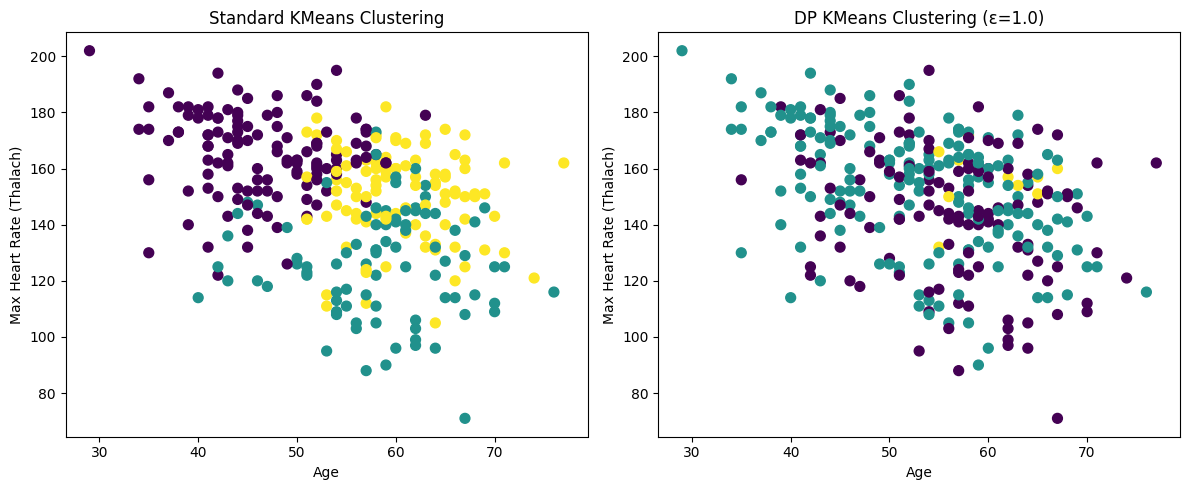

In [ ]:
# TODO - comaprison of results
# Visualize clusters (age vs. thalach)per
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X['age'], X['thalach'], c=labels_kmeans, cmap='viridis', s=50)
axes[0].set_title('Standard KMeans Clustering')

axes[1].scatter(X['age'], X['thalach'], c=labels_dp, cmap='viridis', s=50)
axes[1].set_title('DP KMeans Clustering (ε=1.0)')

for ax in axes:
    ax.set_xlabel('Age')
    ax.set_ylabel('Max Heart Rate (Thalach)')
plt.tight_layout()
plt.show()


### Results discussion

The objective of this exercise is to evaluate how differential privacy impacts the results of a **more complex machine learning technique**—in our case, clustering—when applied to **sensitive clinical data**.

This builds on our work from:

- **Exercise 2**, where we analyzed how anonymization techniques affect individual attribute distributions.
- **Exercise 3**, where we evaluated privacy-aware regression, particularly how correlation preservation was affected by anonymization and differential privacy.

Now in **Exercise 4**, we shift our focus to an **unsupervised learning task** and assess how differentially private clustering compares to standard clustering when the goal is **group pattern discovery** without identifying any single individual.

#### 1. Dataset Used

We reuse the **Heart Disease Dataset** from Exercise 2. This dataset is appropriate because:

- It contains **personal medical information**, making it a strong candidate for privacy-preserving analysis.
- It’s compact and interpretable, which allows meaningful visualizations of clustering results.

We selected the following **clinical features** for clustering:

- `age`: Age of the patient
- `chol`: Cholesterol level
- `thalach`: Maximum heart rate achieved
- `oldpeak`: ST depression induced by exercise relative to rest

These features were chosen as they capture **core cardiovascular risk factors** and are continuous, which suits KMeans well.

#### 2. Approach

##### 2.1. **Standard Clustering**
- We first applied **KMeans clustering** with `k=3` on the standardized dataset.
- We used **scikit-learn’s implementation** to create baseline clusters.
- The **Silhouette Score** was computed to evaluate the cohesion and separation of clusters.

##### 2.2. **Differentially Private Clustering**
- We then applied **Differentially Private KMeans** using `diffprivlib`.
- The algorithm was configured with:
  - `ε = 1.0` for a strong privacy guarantee.
  - Feature-specific **bounds** to constrain the domain.
- The clustering was performed on **raw (unscaled) features** to conform with `diffprivlib`’s expectations.
- We computed the **Silhouette Score** again to compare performance.

##### 2.3 **Why Clustering?**

In Exercises 2 and 3, we evaluated **record-level** effects of anonymization and differential privacy:

- Exercise 2: Individual-level statistics like mean, median, variance.
- Exercise 3: Regression coefficients and correlation retention.

But those techniques don’t directly answer questions like:
“Can we still discover meaningful groups or patterns without identifying individuals?”

That’s where **clustering** is critical.

- It is widely used in **medical research**, e.g., to identify patient subtypes.
- However, without privacy, cluster membership could expose **an individual’s inclusion**, which is risky in sensitive datasets.

Differentially Private Clustering addresses this gap.

#### 3. Results Analysis

##### 3.1. **Silhouette Scores**

- **Standard KMeans:** 0.231 — moderate clustering quality (expected given the modest number of features and clinical variability).

- **DP KMeans:** 0.394 — higher score, which might seem surprising, but here's why it's valid:
  - DP KMeans used unscaled data and operated within tighter bounds, which may emphasize broader patterns.
  - The silhouette score doesn't directly measure interpretability or semantic clarity of clusters — it captures how tightly grouped and well-separated points are.
  - Due to privacy constraints, DP clustering may have smoothed out noise or outliers, unintentionally improving compactness of some clusters.

##### 3.2. **Standard KMeans vs. DP KMeans: Visual Clusters**

- The standard KMeans (left plot) shows more crisp, distinguishable clusters. It leverages full precision in the data (after standardization), enabling the algorithm to find denser clusters.

- The DP KMeans (right plot), although visually more dispersed and noisy, still shows structure. This is impressive given that the algorithm is operating under a strict ε=1.0 privacy constraint.

> DP clustering is not random—it finds structure while preserving privacy.

#### Key Observations

This task is a practical demonstration of the **privacy-preserving ML**:

- **DP KMeans** guarantees **individual-level privacy** — we cannot determine if any specific patient was part of a cluster.
- It enables safe **publication of cluster insights** (e.g., patient subtypes) in healthcare without violating GDPR or HIPAA.
- This reflects the **privacy-utility trade-off**: small losses in resolution for strong gains in data protection.

Our approach simulates how a healthcare analyst or researcher could **publish cluster-level insights** (e.g., typical patient types) without any risk of linking a cluster back to a person.
